# Notebook 1 — Data Generation
This notebook generates the synthetic predictive maintenance dataset and inspects its structure. We call the project module directly to ensure consistency with the production pipeline. The goal is to validate target balance and visualize sensor behavior around failure windows.

## Imports and data generation
We import plotting/data libraries and run `simulate_all_machines()` from `src.data.simulate_data`.

The following cell creates the full synthetic dataset in-memory and stores it in `df`.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.simulate_data import simulate_all_machines

sns.set_theme(style="whitegrid")

df = simulate_all_machines()
df = df.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)
df.head()

Simulating 5 machines | 260,641 time steps each | Sensors: ['temperature', 'vibration', 'pressure', 'rpm', 'current']
  → Generating Machine_1 …
  → Generating Machine_2 …


  → Generating Machine_3 …
  → Generating Machine_4 …


  → Generating Machine_5 …


,timestamp,machine_id,temperature,vibration,pressure,rpm,current,failure_within_48h,time_to_failure
0,2025-01-01 00:00:00,Machine_1,75.993428,2.315037,4.473360,1491.979085,15.393747,0,NaN
1,2025-01-01 00:01:00,Machine_1,74.723471,2.369734,5.447588,1519.024295,14.430274,0,NaN
2,2025-01-01 00:02:00,Machine_1,76.295377,2.358509,5.134485,1508.074185,14.787605,0,NaN
3,2025-01-01 00:03:00,Machine_1,78.046060,2.452708,4.809742,1481.132193,15.239413,0,NaN
4,2025-01-01 00:04:00,Machine_1,74.531693,2.555839,4.699724,1473.959258,15.047301,0,NaN


## Dataset structure
We inspect shape, preview rows, and schema (`dtypes`) to verify data types before downstream processing.

In [2]:
print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))

Shape: (1303205, 9)


,timestamp,machine_id,temperature,vibration,pressure,rpm,current,failure_within_48h,time_to_failure
0,2025-01-01 00:00:00,Machine_1,75.993428,2.315037,4.473360,1491.979085,15.393747,0,NaN
1,2025-01-01 00:01:00,Machine_1,74.723471,2.369734,5.447588,1519.024295,14.430274,0,NaN
2,2025-01-01 00:02:00,Machine_1,76.295377,2.358509,5.134485,1508.074185,14.787605,0,NaN
3,2025-01-01 00:03:00,Machine_1,78.046060,2.452708,4.809742,1481.132193,15.239413,0,NaN
4,2025-01-01 00:04:00,Machine_1,74.531693,2.555839,4.699724,1473.959258,15.047301,0,NaN


,dtype
timestamp,datetime64[us]
machine_id,str
temperature,float64
vibration,float64
pressure,float64
rpm,float64
current,float64
failure_within_48h,int32
time_to_failure,float64


## Class balance
A predictive maintenance target is usually imbalanced. We compute absolute counts and percentages for `failure_within_48h`.

In [3]:
counts = df["failure_within_48h"].value_counts().sort_index()
perc = (counts / counts.sum() * 100).round(2)
class_balance = pd.DataFrame({"count": counts, "percentage": perc})
display(class_balance)

,count,percentage
failure_within_48h,,
0,1190885,91.38
1,112320,8.62


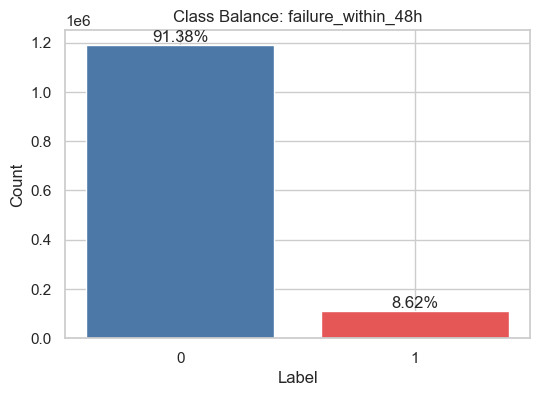

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(class_balance.index.astype(str), class_balance["count"], color=["#4C78A8", "#E45756"])
ax.set_title("Class Balance: failure_within_48h")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
for i, (idx, row) in enumerate(class_balance.iterrows()):
    ax.text(i, row["count"], f"{row['percentage']}%", ha="center", va="bottom")
plt.show()

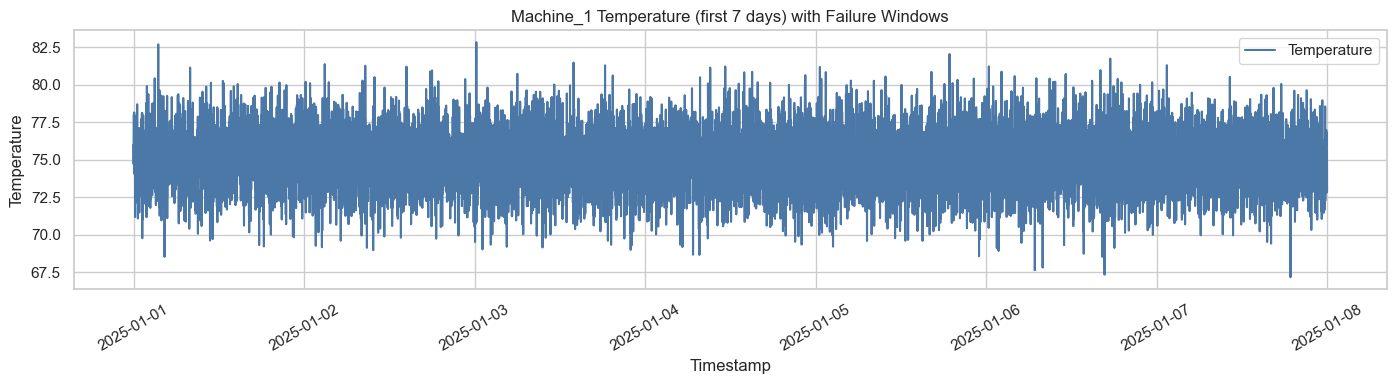

In [5]:
machine = "Machine_1"
m1 = df[df["machine_id"] == machine].copy()
start = m1["timestamp"].min()
end = start + pd.Timedelta(days=7)
m1_7d = m1[(m1["timestamp"] >= start) & (m1["timestamp"] < end)].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(m1_7d["timestamp"], m1_7d["temperature"], color="#4C78A8", label="Temperature")

in_window = m1_7d["failure_within_48h"].eq(1).to_numpy()
times = m1_7d["timestamp"].to_numpy()
for i in range(len(m1_7d) - 1):
    if in_window[i]:
        ax.axvspan(times[i], times[i + 1], color="red", alpha=0.08)

ax.set_title("Machine_1 Temperature (first 7 days) with Failure Windows")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Multi-sensor view for one machine
We plot all five sensors for `Machine_1` over the same 7-day window to understand joint dynamics.

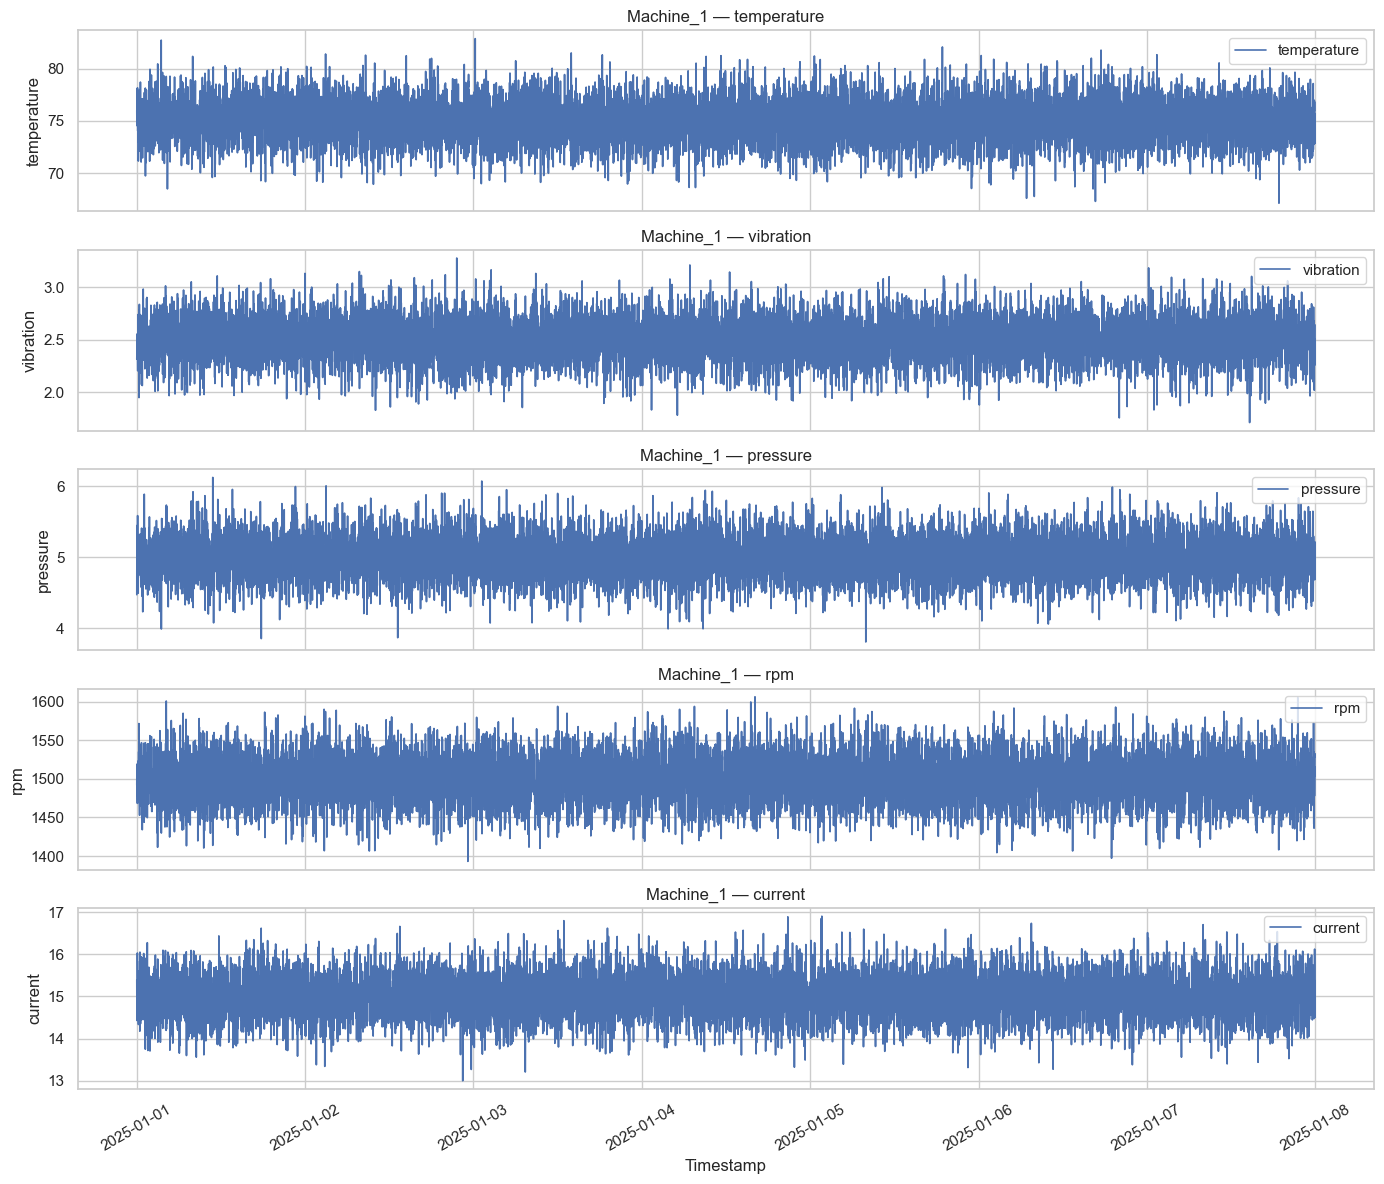

In [6]:
sensors = ["temperature", "vibration", "pressure", "rpm", "current"]
fig, axes = plt.subplots(len(sensors), 1, figsize=(14, 12), sharex=True)

for ax, sensor in zip(axes, sensors):
    ax.plot(m1_7d["timestamp"], m1_7d[sensor], label=sensor, linewidth=1.2)
    ax.set_title(f"Machine_1 — {sensor}")
    ax.set_ylabel(sensor)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Timestamp")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The dataset generation step is validated and ready for EDA + preprocessing in Notebook 2.